# Model A: Original-Image Transfer-Learning Baseline

This notebook trains Model A on the original 128×128 images. The committed training and validation split files are used for optimization and model selection. The untouched test split is intentionally not loaded until the final evaluation stage.

## Environment

Run the data-exploration notebook first when using a new Colab runtime. It mounts Drive, clones the public repository, restores the dataset, and creates the reproducible split CSVs.

In [ ]:
from pathlib import Path
import importlib
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)

GITHUB_REPO_URL = 'https://github.com/shaverm96/DSBA-6165-Sum-2026-Take-Home-Exam.git'
COLAB_REPO_DIR = Path('/content/Applied-AI-Midterm')

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if (COLAB_REPO_DIR / '.git').exists():
        pull_result = subprocess.run(
            ['git', 'pull', '--ff-only', 'origin', 'main'],
            cwd=COLAB_REPO_DIR,
            capture_output=True,
            text=True,
        )
        if pull_result.returncode != 0:
            raise RuntimeError(f'Could not update the Colab repository: {pull_result.stderr.strip()}')
        print(pull_result.stdout.strip() or 'Colab repository is already up to date.')
    else:
        clone_result = subprocess.run(
            ['git', 'clone', GITHUB_REPO_URL, str(COLAB_REPO_DIR)],
            capture_output=True,
            text=True,
        )
        if clone_result.returncode != 0:
            raise RuntimeError(f'Could not clone the repository: {clone_result.stderr.strip()}')
        print('Cloned the latest public repository.')
    PROJECT_ROOT = COLAB_REPO_DIR
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

required_source = PROJECT_ROOT / 'src' / 'models' / 'classifier.py'
if not required_source.exists():
    raise FileNotFoundError(
        f'Model A source is missing from {PROJECT_ROOT}. Pull the latest repository commit first.'
    )

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'config.yaml'
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Configuration file not found: {CONFIG_PATH}')

with CONFIG_PATH.open('r', encoding='utf-8') as stream:
    CONFIG = yaml.safe_load(stream)

from src.data.dataset import ImageClassificationDataset
from src.data.transforms import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    get_classifier_transforms,
)
from src.models.classifier import ResNet18Classifier
import src.training.train_classifier as train_classifier_module
from src.utils.device import get_device
from src.utils.reproducibility import set_seed

importlib.reload(train_classifier_module)
build_classification_loaders = train_classifier_module.build_classification_loaders
train_classifier = train_classifier_module.train_classifier

set_seed(int(CONFIG['seed']))
DEVICE = get_device()
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')

Already up to date.
Project root: /content/Applied-AI-Midterm
Device: cuda
CUDA available: True


In [ ]:
TRAINING_CONFIG = CONFIG['training']
DATASET_CONFIG = CONFIG['dataset']
SPLIT_DIR = PROJECT_ROOT / CONFIG['paths']['splits_dir']

split_tables = {
    'train': pd.read_csv(SPLIT_DIR / 'train_split.csv'),
    'validation': pd.read_csv(SPLIT_DIR / 'val_split.csv'),
}
for split_name, split_table in split_tables.items():
    print(f'{split_name.title()} examples: {len(split_table):,}')
    print(split_table['label'].value_counts().sort_index().to_dict())

train_loader, validation_loader = build_classification_loaders(
    split_dir=SPLIT_DIR,
    class_names=DATASET_CONFIG['classes'],
    image_size=int(TRAINING_CONFIG['image_size']),
    batch_size=int(TRAINING_CONFIG['batch_size']),
    num_workers=int(TRAINING_CONFIG['num_workers']),
)

images, labels, image_paths = next(iter(train_loader))
assert tuple(images.shape[1:]) == (3, 128, 128), images.shape
assert labels.ndim == 1, labels.shape
assert len(image_paths) == images.shape[0]

print(f'Batch image shape: {tuple(images.shape)}')
print(f'Batch label shape: {tuple(labels.shape)}')
print('The test split is reserved for the final evaluation cell.')

Train examples: 14,833
{'cats': 7420, 'dogs': 7413}
Validation examples: 2,618
{'cats': 1310, 'dogs': 1308}
Batch image shape: (32, 3, 128, 128)
Batch label shape: (32,)
The test split is reserved for the final evaluation cell.


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)
Total parameters: 11,177,025


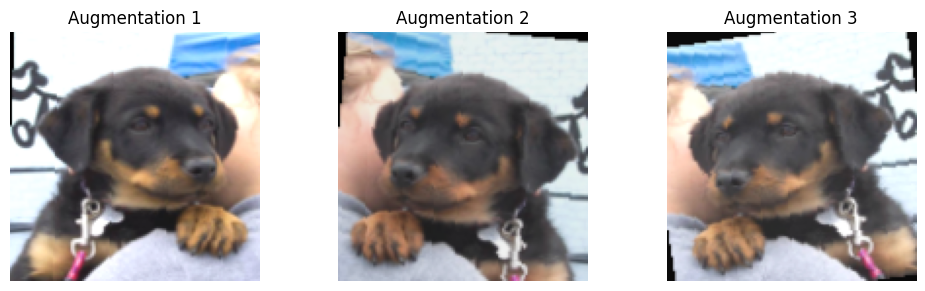

In [11]:
CLASSIFIER_CONFIG = CONFIG['model']['classifier']
model_preview = ResNet18Classifier(
    pretrained=False,
    dropout=float(CLASSIFIER_CONFIG['classifier_dropout']),
)
parameter_count = sum(parameter.numel() for parameter in model_preview.parameters())
print(model_preview.classifier)
print(f'Total parameters: {parameter_count:,}')

transform_map = get_classifier_transforms(image_size=128)
sample_image = Image.open(image_paths[0]).convert('RGB')
preview_images = [transform_map['train'](sample_image) for _ in range(3)]
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
preview_images = [torch.clamp(image * std + mean, 0, 1).permute(1, 2, 0) for image in preview_images]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for axis, image, title in zip(axes, preview_images, ['Augmentation 1', 'Augmentation 2', 'Augmentation 3']):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## Model A frozen transfer-learning baseline

Following the Assignment 1 workflow, the pretrained ResNet18 backbone is frozen first and only the new binary classification head is trained. The validation split is used for monitoring and early stopping; the test split remains untouched.

In [12]:
model = ResNet18Classifier(
    pretrained=bool(CLASSIFIER_CONFIG['pretrained']),
    dropout=float(CLASSIFIER_CONFIG['classifier_dropout']),
)
frozen_epochs = int(TRAINING_CONFIG.get('classifier_freeze_epochs', 1))
checkpoint_root = PROJECT_ROOT / CONFIG['paths']['model_dir']

frozen_history = train_classifier(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    device=DEVICE,
    epochs=frozen_epochs,
    learning_rate=float(CLASSIFIER_CONFIG['learning_rate']),
    weight_decay=float(CLASSIFIER_CONFIG['weight_decay']),
    patience=int(TRAINING_CONFIG['early_stopping_patience']),
    checkpoint_dir=checkpoint_root / 'model_a_frozen',
    freeze_backbone_epochs=frozen_epochs,
)

frozen_history_df = pd.DataFrame(frozen_history)
frozen_history_df

Epoch 001/001 | train loss 0.5284 | validation loss 0.3482 | validation F1 0.8629


,epoch,learning_rate,train_accuracy,train_precision,train_recall,train_f1,train_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_loss
0,1.0,0.0001,0.730196,0.725387,0.740456,0.732844,0.528383,0.869748,0.910093,0.820336,0.862887,0.348168


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
frozen_history_df.plot(x='epoch', y=['train_loss', 'validation_loss'], ax=axes[0])
axes[0].set_title('Frozen ResNet18 loss')
axes[0].set_ylabel('BCE loss')
frozen_history_df.plot(x='epoch', y=['train_accuracy', 'validation_accuracy', 'validation_f1'], ax=axes[1])
axes[1].set_title('Frozen ResNet18 validation metrics')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

## Model A fine-tuning phase

The top-level transfer-learning baseline is now fine-tuned by unfreezing the ResNet18 backbone. A smaller learning rate is used, and the best fine-tuned checkpoint is selected using validation loss.

In [ ]:
fine_tune_epochs = max(int(TRAINING_CONFIG['classifier_epochs']) - frozen_epochs, 1)
fine_tune_checkpoint_dir = checkpoint_root / 'model_a'
fine_tune_resume = fine_tune_checkpoint_dir / 'last.pt'
if not fine_tune_resume.exists():
    fine_tune_resume = None
    print('Starting fine-tuning from the frozen checkpoint.')
else:
    print(f'Resuming fine-tuning from {fine_tune_resume}.')

fine_tune_history = train_classifier(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    device=DEVICE,
    epochs=fine_tune_epochs,
    learning_rate=float(CLASSIFIER_CONFIG['learning_rate']) / 10,
    weight_decay=float(CLASSIFIER_CONFIG['weight_decay']),
    patience=int(TRAINING_CONFIG['early_stopping_patience']),
    checkpoint_dir=fine_tune_checkpoint_dir,
    resume_from=fine_tune_resume,
    freeze_backbone_epochs=0,
)

fine_tune_history_df = pd.DataFrame(fine_tune_history)
history_df = pd.concat(
    [frozen_history_df, fine_tune_history_df.assign(epoch=lambda frame: frame['epoch'] + frozen_epochs)],
    ignore_index=True,
)
fine_tune_history_df.tail()

Epoch 001/029 | train loss 0.2061 | validation loss 0.1109 | validation F1 0.9497
Epoch 002/029 | train loss 0.1209 | validation loss 0.0916 | validation F1 0.9604
Epoch 003/029 | train loss 0.0982 | validation loss 0.0791 | validation F1 0.9654
Epoch 004/029 | train loss 0.0822 | validation loss 0.0764 | validation F1 0.9667
Epoch 005/029 | train loss 0.0714 | validation loss 0.0726 | validation F1 0.9680
Epoch 006/029 | train loss 0.0615 | validation loss 0.0701 | validation F1 0.9729


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
history_df.plot(x='epoch', y=['train_loss', 'validation_loss'], ax=axes[0])
axes[0].set_title('Model A loss')
axes[0].set_ylabel('BCE loss')
history_df.plot(x='epoch', y=['train_accuracy', 'validation_accuracy', 'validation_f1'], ax=axes[1])
axes[1].set_title('Model A validation history')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

In [ ]:
test_transform = get_classifier_transforms(image_size=128)['test']
test_dataset = ImageClassificationDataset(
    split_csv=SPLIT_DIR / 'test_split.csv',
    class_names=DATASET_CONFIG['classes'],
    transform=test_transform,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=int(TRAINING_CONFIG['batch_size']),
    shuffle=False,
    num_workers=int(TRAINING_CONFIG['num_workers']),
    pin_memory=DEVICE.type == 'cuda',
)

model.eval()
all_probabilities = []
all_targets = []
with torch.inference_mode():
    for batch_images, batch_labels, _ in test_loader:
        logits = model(batch_images.to(DEVICE, non_blocking=DEVICE.type == 'cuda'))
        all_probabilities.append(torch.sigmoid(logits).cpu())
        all_targets.append(batch_labels.cpu())

probabilities = torch.cat(all_probabilities).numpy()
targets = torch.cat(all_targets).numpy().astype(int)
predictions = (probabilities >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(targets, probabilities)
metrics = {
    'accuracy': accuracy_score(targets, predictions),
    'precision': precision_score(targets, predictions, zero_division=0),
    'recall': recall_score(targets, predictions, zero_division=0),
    'f1': f1_score(targets, predictions, zero_division=0),
    'roc_auc': auc(fpr, tpr),
}
print(pd.Series(metrics).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(
    confusion_matrix(targets, predictions),
    display_labels=DATASET_CONFIG['classes'],
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Model A test confusion matrix')
axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Model A test ROC curve')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## Final Model A test evaluation

Only after training and validation-based checkpoint selection do we load the untouched test split. This cell reports the required classification metrics and displays the confusion matrix and ROC curve.

## Checkpoint and resume

Training writes separate frozen and fine-tuned checkpoints under `models/checkpoints/`, plus the history JSON under `logs/`. If training is interrupted, resume the corresponding phase with the `last.pt` checkpoint through `train_classifier`.